# Positional Embedding Analysis: Trained vs Untrained Positions

The N2 model was trained with cluster size 2 (observation_size=2), ground_truth_length=110.
Positions beyond what was seen during training were never updated by gradients, they are still random init.

**Goal:** visualize the embeddings and see if we can spot where the boundary is, without assuming it.

In [1]:
%matplotlib inline
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load checkpoint directly to GPU
ckpt_path = '/mnt/model_checkpoints/FixedN/N2/checkpoint_best.pt'
ckpt = torch.load(ckpt_path, map_location=device)
state_dict = {k.replace('_orig_mod.', ''): v for k, v in ckpt['model'].items()}

# Extract positional embeddings: shape (block_size, n_embd) = (1500, 512)
pos_emb = state_dict['transformer.wpe.weight'].float().cpu().numpy()
print(f'Positional embedding shape: {pos_emb.shape}')
print(f'block_size={pos_emb.shape[0]}, n_embd={pos_emb.shape[1]}')

Positional embedding shape: (1500, 512)
block_size=1500, n_embd=512



The N2 model has 1500 positional embedding vectors (one per position). We plot the L2 norm of each to find where trained positions end and untrained ones begin.

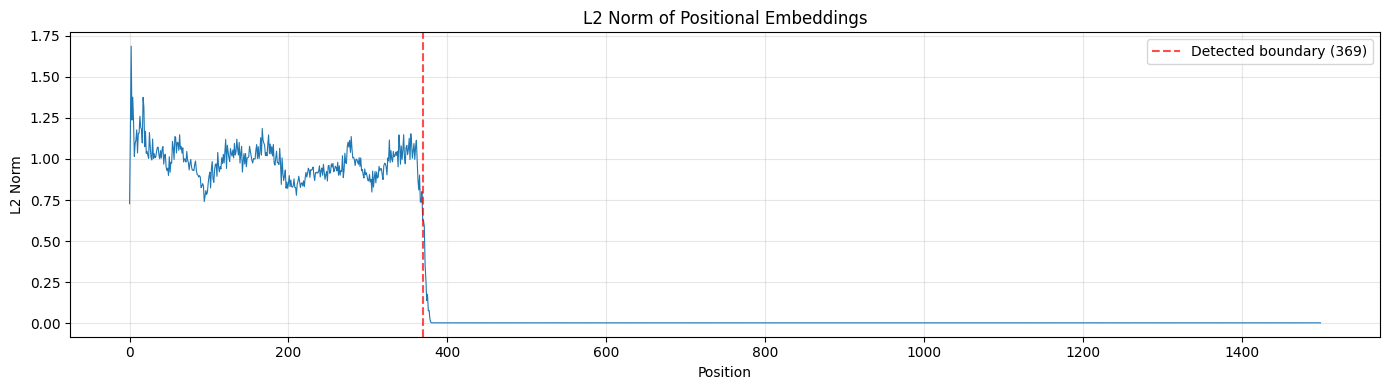

Boundary at position 369
Trained (0-369):   mean norm = 0.9833
Untrained (369-1500): mean norm = 0.0054


In [2]:
norms = np.linalg.norm(pos_emb, axis=1)
variances = np.var(pos_emb, axis=1)

# Detect boundary
window = 30
smoothed_norms = np.convolve(norms, np.ones(window)/window, mode='valid')
norm_diff = np.abs(np.diff(smoothed_norms))
transition_pos = np.argmax(norm_diff) + window // 2

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(norms, linewidth=0.8)
ax.axvline(x=transition_pos, color='red', linestyle='--', alpha=0.7, label=f'Detected boundary ({transition_pos})')
ax.set_xlabel('Position')
ax.set_ylabel('L2 Norm')
ax.set_title('L2 Norm of Positional Embeddings')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Boundary at position {transition_pos}')
print(f'Trained (0-{transition_pos}):   mean norm = {norms[:transition_pos].mean():.4f}')
print(f'Untrained ({transition_pos}-1500): mean norm = {norms[transition_pos:].mean():.4f}')


Since positional embeddings are ~zero beyond position 369, we expect that all A's (or all G's, etc.) in untrained traces have **identical representations** and the model cannot distinguish between an A at position 400 vs position 600.

We check this by computing pairwise cosine similarity of same-token hidden states:
- **Within each read**: are all A's in trace 5 the same?
- **Across untrained reads**: is an A in trace 5 the same as an A in trace 6?
- **Compared to trained reads**: are A's in traces 1-2 still distinguishable?

In [3]:
import sys, pickle, random
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))
from src.data_pkg.IDS_channel import IDS_channel

with open('/workspaces/TReconLM/src/data_pkg/meta_nuc.pkl', 'rb') as f:
    meta = pickle.load(f)
stoi, itos = meta['stoi'], meta['itos']
encode_str = lambda s: [stoi[ch] for ch in s]

channel_stats = {'substitution_probability': 0.02, 'deletion_probability': 0.03, 'insertion_probability': 0.05}

# Load model for representation and attention analysis
from src.gpt_pkg.model import GPT, GPTConfig

config_args = {k: v for k, v in ckpt['model_args'].items() if k != 'model_type'}
model = GPT(GPTConfig(**config_args))
clean_sd = {k.replace('_orig_mod.', ''): v for k, v in ckpt['model'].items()}
model.load_state_dict(clean_sd, strict=True)
model = model.to(device).eval()
print(f'Model loaded on {device}')

rng = random.Random(42)
gt = ''.join(rng.choice('ACGT') for _ in range(110))

def make_input(gt, n_reads, rng):
    reads = [IDS_channel(gt, channel_stats, rng) for _ in range(n_reads)]
    return '|'.join(reads) + ':'

all_cs = list(range(2, 11))
all_inputs = {cs: make_input(gt, cs, random.Random(42)) for cs in all_cs}
for cs in all_cs:
    print(f'CS {cs}: input length = {len(all_inputs[cs])} tokens')


FlashAttention available (will be used during training and inference with KV cache)
Model loaded on cuda
CS 2: input length = 217 tokens
CS 3: input length = 333 tokens
CS 4: input length = 446 tokens
CS 5: input length = 560 tokens
CS 6: input length = 670 tokens
CS 7: input length = 785 tokens
CS 8: input length = 899 tokens
CS 9: input length = 1009 tokens
CS 10: input length = 1119 tokens


  Read 1: pos 0-113 (TRAINED)
  Read 2: pos 114-216 (TRAINED)
  Read 3: pos 217-332 (TRAINED)
  Read 4: pos 333-445 (UNTRAINED)
  Read 5: pos 446-559 (UNTRAINED)
  Read 6: pos 560-669 (UNTRAINED)
  Read 7: pos 670-784 (UNTRAINED)


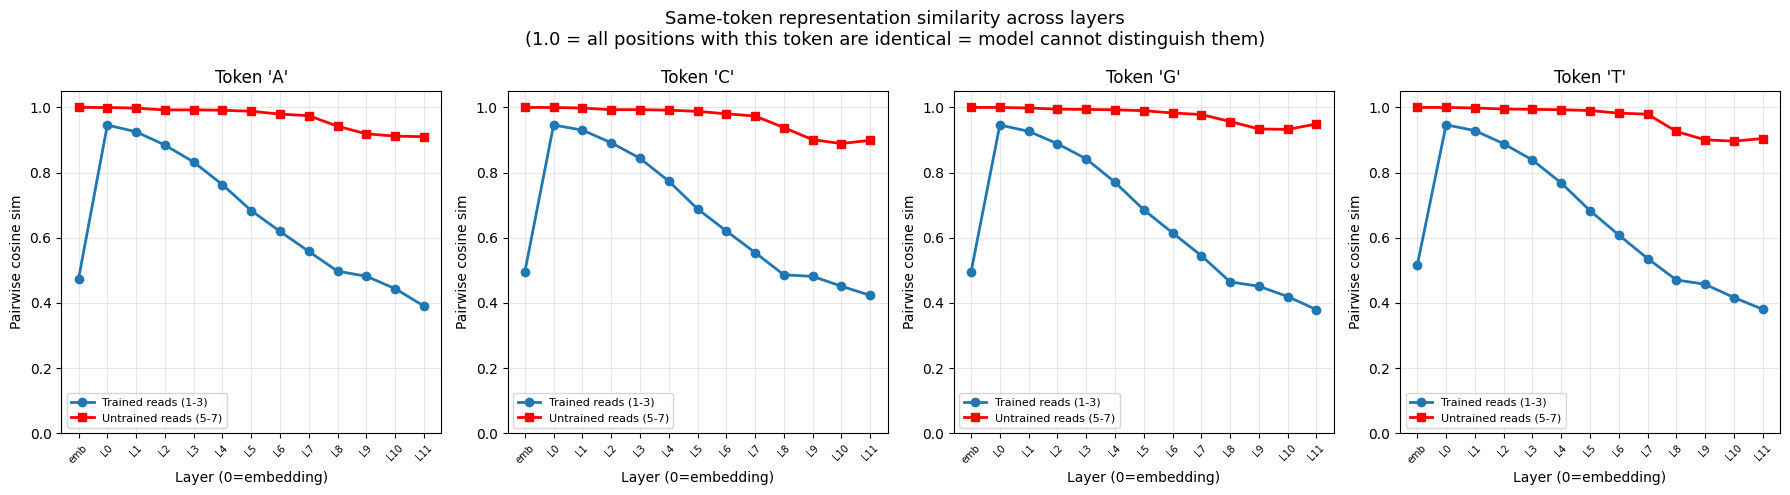


Pairwise cosine similarity: trained vs untrained reads, per nucleotide, per layer
Layer | A trained | A untrained | C trained | C untrained | G trained | G untrained | T trained | T untrained
-------------------------------------------------------------------------------------
  emb |    0.4740  |     1.0000    |    0.4947  |     1.0000    |    0.4951  |     1.0000    |    0.5161  |     1.0000   
   L0 |    0.9459  |     0.9998    |    0.9461  |     0.9998    |    0.9460  |     0.9998    |    0.9466  |     0.9998   
   L1 |    0.9253  |     0.9980    |    0.9303  |     0.9981    |    0.9268  |     0.9983    |    0.9288  |     0.9983   
   L2 |    0.8845  |     0.9922    |    0.8917  |     0.9931    |    0.8887  |     0.9947    |    0.8886  |     0.9950   
   L3 |    0.8324  |     0.9925    |    0.8439  |     0.9931    |    0.8422  |     0.9939    |    0.8385  |     0.9941   
   L4 |    0.7629  |     0.9913    |    0.7739  |     0.9916    |    0.7703  |     0.9927    |    0.7681  |    

In [4]:
# Are all A's (or C's, G's, T's) in untrained traces identical?
# Feed CS7 input through the model and extract hidden states at every position after every layer.
# Then check: within untrained reads, do all positions with the same nucleotide have the same representation?

def get_all_hidden_states(model, input_str, device):
    tokens = encode_str(input_str)
    x = torch.tensor([tokens], dtype=torch.long, device=device)
    with torch.no_grad():
        b, t = x.size()
        pos = torch.arange(t, device=device)[None, :].expand(b, -1)
        h = model.transformer.wte(x) + model.transformer.wpe(pos)
        h = model.transformer.drop(h)
        layer_states = [h[0].cpu().numpy()]  # after embedding
        for block in model.transformer.h:
            h, _ = block(h)
            layer_states.append(h[0].cpu().numpy())  # after each layer
    return layer_states  # 13 arrays of shape (T, 512): embedding + 12 layers

states_7 = get_all_hidden_states(model, all_inputs[7], device)
input_tokens_7 = encode_str(all_inputs[7])

# Find read boundaries
sep_positions = [j for j, t in enumerate(input_tokens_7) if t == 5]
read_ranges = []
start = 0
for sp in sep_positions:
    read_ranges.append((start, sp))
    start = sp + 1
read_ranges.append((start, len(input_tokens_7) - 1))

for idx, (rs, re) in enumerate(read_ranges):
    region = "TRAINED" if re < 369 else "UNTRAINED"
    print(f"  Read {idx+1}: pos {rs}-{re} ({region})")

def pairwise_cos(vecs):
    if len(vecs) < 2:
        return np.nan
    nrm = np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-8
    normed = vecs / nrm
    cos = normed @ normed.T
    idx = np.triu_indices(len(vecs), k=1)
    return cos[idx].mean()

# For each nucleotide: across-all-untrained vs across-all-trained, at every layer
token_id_to_name = {0: 'A', 1: 'C', 2: 'G', 3: 'T'}
layer_labels = ['emb'] + [f'L{i}' for i in range(12)]

# Collect data for plotting
plot_data = {}  # {nuc: {'trained': [sim_per_layer], 'untrained': [sim_per_layer]}}

for nuc_id, nuc_name in token_id_to_name.items():
    trained_sims = []
    untrained_sims = []
    
    for layer_idx in range(13):
        h = states_7[layer_idx]
        
        trained_positions = []
        for rs, re in read_ranges:
            if re < 369:
                trained_positions.extend([j for j in range(rs, re) if input_tokens_7[j] == nuc_id])
        
        untrained_positions = []
        for rs, re in read_ranges:
            if rs >= 369:
                untrained_positions.extend([j for j in range(rs, re) if input_tokens_7[j] == nuc_id])
        
        trained_sims.append(pairwise_cos(h[trained_positions]) if len(trained_positions) >= 2 else np.nan)
        untrained_sims.append(pairwise_cos(h[untrained_positions]) if len(untrained_positions) >= 2 else np.nan)
    
    plot_data[nuc_name] = {'trained': trained_sims, 'untrained': untrained_sims}

# Plot: one subplot per nucleotide, x = layer, y = cosine sim
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for idx, (nuc_name, data) in enumerate(plot_data.items()):
    ax = axes[idx]
    ax.plot(range(13), data['trained'], marker='o', linewidth=2, label='Trained reads (1-3)')
    ax.plot(range(13), data['untrained'], marker='s', linewidth=2, color='red', label='Untrained reads (5-7)')
    ax.set_xlabel('Layer (0=embedding)')
    ax.set_ylabel('Pairwise cosine sim')
    ax.set_title(f"Token '{nuc_name}'")
    ax.set_xticks(range(13))
    ax.set_xticklabels(layer_labels, fontsize=7, rotation=45)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Same-token representation similarity across layers\n'
             '(1.0 = all positions with this token are identical = model cannot distinguish them)',
             fontsize=13)
plt.tight_layout()
plt.show()

# Print table
print("\nPairwise cosine similarity: trained vs untrained reads, per nucleotide, per layer")
print(f"{'Layer':>5}", end="")
for nuc in 'ACGT':
    print(f" | {nuc} trained | {nuc} untrained", end="")
print()
print('-' * 85)
for layer_idx in range(13):
    print(f"{layer_labels[layer_idx]:>5}", end="")
    for nuc in 'ACGT':
        t = plot_data[nuc]['trained'][layer_idx]
        u = plot_data[nuc]['untrained'][layer_idx]
        print(f" |    {t:.4f}  |     {u:.4f}   ", end="")
    print()
